# 21_因果推断基础-从相关到因果：潜在结局与处理效应

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元。需要 NumPy、pandas 和 Matplotlib；在 Jupyter 中选择 Python 内核即可。

本篇数据：书中的肾结石治疗汇总表，以及按潜在结局模型生成的模拟数据。数据均在代码中给出，不需要下载文件，也不依赖 `notebook_support.py`。

肾结石案例来自参考资料 [1] 的第 1 章；模拟模型沿用其第 2.3 节，并增加了结果分解和重复模拟。书中的 R 代码在这里改写为 Python，随机数实现不同，不要求模拟数值与原书逐项相同。

代码输出和图形均保存在 Notebook 中。重新运行请使用 **Restart Kernel and Run All Cells**；下文数值解释对应默认参数；修改随机种子后，以新的代码输出为准。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

%matplotlib inline

# 按实际安装的字体选择，沿用原笔记的中文显示方式。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS,
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

SEED_DATA = 42
SEED_ASSIGN = 2026
SEED_MC = 2027
SEED_SIZE = 2028

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8


前面讲回归和分类时，我们主要关心怎么把结果预测得更准。到了因果推断，问题稍微变了一下。

比如，参加培训的人收入更高，是不是说明培训提高了收入？不一定。参加培训的人，可能原本就有更多工作经验，也可能更愿意投入时间学习。

我们真正想比较的是：**同一个人参加培训与不参加培训，收入会相差多少？** 但数据里通常是参加培训的一批人，与没有参加培训的另一批人。两种比较不是一回事。

下面先把这个区别写成公式，再用两个案例算一遍。

## 理论基础

### 1. 潜在结局：一个人，两种处理状态

把是否接受某种处理记为 $T$：$T=1$ 表示接受处理，$T=0$ 表示对照。这里的“处理”不只指治疗，也可以是参加培训、收到一条提醒，或者采用一种新的教学方式。

对第 $i$ 个人，定义两个潜在结局：

$$
Y_i(1)\quad\text{和}\quad Y_i(0).
$$

$Y_i(1)$ 是他接受处理时的结果，$Y_i(0)$ 是他不接受处理时的结果。它们比较的是同一个研究对象、同一时间条件下的两种处理状态。[1，第 2.2 节；2，第 2.1 节]

举个便于计算的小例子。假设下面两个学生在“参加同一项辅导”和“不参加辅导”两种状态下的考试成绩如下。这些数字是人为设定的，不是实测数据。

| 学生 | 不参加辅导 $Y_i(0)$ | 参加辅导 $Y_i(1)$ | 两者之差 |
|---|---:|---:|---:|
| A | 60 | 68 | 8 |
| B | 75 | 74 | -1 |

辅导对 A 的作用是增加 8 分，对 B 的作用是减少 1 分。这个差就是个体处理效应：

$$
\tau_i=Y_i(1)-Y_i(0).
$$

这里成绩越高越好，所以正值表示有益。换成住院天数这样的结局，正负号的实际含义就要反过来看。

本篇统一用 $T$ 表示处理。参考资料 [1] 使用 $Z$，[2] 多使用 $D$，它们在这里表示同一类变量。

### 2. 为什么不能直接算出每个人的效应？

一个学生在这次考试前要么参加辅导，要么不参加。实际观察到的成绩只有一个：

$$
Y_i=T_iY_i(1)+(1-T_i)Y_i(0).
$$

当 $T_i=1$ 时，右边只剩下 $Y_i(1)$；当 $T_i=0$ 时，只剩下 $Y_i(0)$。另一个未被观察到的潜在结局，就是相对于实际处理状态的反事实结局。

如果 A 参加辅导、B 没参加，我们只能看到 A 的 68 分和 B 的 75 分。直接相减得到 $68-75=-7$，并不是 A 的 8 分，也不是 B 的 -1 分。这是两个人之间的差异，不是同一个人的处理效应。

把所有人的两个潜在结局列出来，Ding 称之为 **Science Table（潜在结局完整表）**。现实数据通常只能揭示每行的一项；模拟实验则可以把两项都保留下来，用于核对答案。[1，第 2.2–2.3 节]

这里还隐含了两个前提：处理方式定义清楚，没有混在一起的不同版本；一个人的结局不受其他人处理状态的影响。两者合称 SUTVA。比如“参加辅导”需要说明是哪项辅导、持续多久，而不能把完全不同的课程都当成同一种处理。[1，第 2.2 节]

### 3. ATE 和 ATT：平均的是哪些人？

如果能看到完整表，把每个人的效应取平均，就得到这 $n$ 个人的平均处理效应：

$$
\operatorname{ATE}_n
=\frac{1}{n}\sum_{i=1}^{n}\{Y_i(1)-Y_i(0)\}
=\frac{1}{n}\sum_{i=1}^{n}Y_i(1)-\frac{1}{n}\sum_{i=1}^{n}Y_i(0).
$$

注意，两边平均的都是同一批人。前面两个学生的平均效应是 $(8-1)/2=3.5$ 分。

如果研究对象来自一个更大的总体，则总体平均处理效应写成：

$$
\operatorname{ATE}=E[Y(1)-Y(0)].
$$

ATE 是 Average Treatment Effect 的缩写。Ding 也把平均因果效应称为 ACE。本篇用 $\operatorname{ATE}_n$ 区分模拟样本的真实平均效应与总体 ATE；前者是完整表中的真值，不是用观察数据算出的估计值。[1，第 2.2 节；2，第 2.1 节]

另一个常见目标是已处理者的平均效应 ATT（Average Treatment Effect on the Treated）：

$$
\operatorname{ATT}=E[Y(1)-Y(0)\mid T=1].
$$

它问的是：“实际参加了培训的这些人，相比于他们自己不参加培训的情况，平均改变了多少？”仍然是同一批人之间的反事实比较，不是拿他们去和未参加者直接相减。[1，第 10.2 节；2，第 5.5 节，其中也写作 ATET]

如果更容易受益的人更常接受处理，ATT 就可能高于 ATE。后面的模拟会把这两个数分别算出来。

### 4. 观察到的均值差里，混进了什么？

数据里最容易计算的是两组观察结局的均值差：

$$
\Delta=E[Y\mid T=1]-E[Y\mid T=0].
$$

利用 $Y=TY(1)+(1-T)Y(0)$，再加上并减去 $E[Y(0)\mid T=1]$，可以得到：

$$
\begin{aligned}
\Delta
&=E[Y(1)\mid T=1]-E[Y(0)\mid T=0]\\
&=\underbrace{E[Y(1)-Y(0)\mid T=1]}_{\operatorname{ATT}}
+\underbrace{E[Y(0)\mid T=1]-E[Y(0)\mid T=0]}_{\text{选择偏差项}}.
\end{aligned}
$$

第二项的意思是：即使都不接受处理，两组人的结局本来就可能不同。它不是“处理前实测值之差”，而是两组人在不处理状态下的潜在结局均值之差；现实中不能直接完整观察。[1，第 10.2 节]

如果处理是随机分配的，与潜在结局独立，那么在总体层面：

$$
E[Y\mid T=t]=E[Y(t)\mid T=t]=E[Y(t)],\qquad t\in\{0,1\}.
$$

于是两组均值差就等于 ATE。这里还要求两种处理状态都有非零概率。[2，第 2.1 节]

但一次随机分组仍可能有偶然不平衡。随机分配不保证每次算出的均值差恰好等于真实效应，这一点也会在代码里看到。

## 完整案例一：辛普森悖论

先看参考资料 [1] 第 1.3 节的肾结石案例。原书引用 Charig 等（1986）的汇总数据，比较开放手术（$T=1$）与小切口穿刺手术（$T=0$）的治疗成功情况。这里保留原书的处理编码，用它练习汇总和分层计算，不据此给出治疗建议。

### 1. 加载和查看数据

数据只有四行，每行是一种结石大小与一种处理方式的组合。“成功数”和“失败数”来自书中的列联表，其余列由代码计算。

In [2]:
# 参考资料 [1] 第 1.3 节，正文第 7–8 页；这里只录入书中的汇总计数。
stone = pd.DataFrame({
    "结石大小": ["小结石", "小结石", "大结石", "大结石"],
    "T": [1, 0, 1, 0],
    "成功数": [81, 234, 192, 55],
    "失败数": [6, 36, 71, 25],
})
stone["总人数"] = stone["成功数"] + stone["失败数"]
stone["成功率"] = stone["成功数"] / stone["总人数"]

assert stone["总人数"].sum() == 700
assert (stone[["成功数", "失败数"]].to_numpy() >= 0).all()
display(stone.round(4))

,结石大小,T,成功数,失败数,总人数,成功率
0,小结石,1,81,6,87,0.9310
1,小结石,0,234,36,270,0.8667
2,大结石,1,192,71,263,0.7300
3,大结石,0,55,25,80,0.6875


### 2. 先不区分结石大小

先把同一种处理的成功数和总人数加起来，再计算整体成功率。不能直接对两行成功率取平均，因为两行的人数不同。

In [3]:
overall = stone.groupby("T")[["成功数", "失败数", "总人数"]].sum()
overall["成功率"] = overall["成功数"] / overall["总人数"]
crude_diff = overall.loc[1, "成功率"] - overall.loc[0, "成功率"]

display(overall.round(4))
print(f"T=1 的整体成功率：{overall.loc[1, '成功率']:.2%}")
print(f"T=0 的整体成功率：{overall.loc[0, '成功率']:.2%}")
print(f"整体成功率之差（T=1 减 T=0）：{100 * crude_diff:.2f} 个百分点")

np.testing.assert_array_equal(overall["总人数"].to_numpy(), [350, 350])
np.testing.assert_allclose(crude_diff, 273 / 350 - 289 / 350)

,成功数,失败数,总人数,成功率
T,,,,
0,289,61,350,0.8257
1,273,77,350,0.7800


T=1 的整体成功率：78.00%
T=0 的整体成功率：82.57%
整体成功率之差（T=1 减 T=0）：-4.57 个百分点


按整体成功率看，$T=1$ 比 $T=0$ 低了约 4.57 个百分点。这只是当前两组人的观察结果之差。原书把比例四舍五入为 78% 和 83%，这里保留两位小数。

### 3. 按结石大小分别计算

现在把小结石与大结石分开，计算各层的成功率。相减的方向仍然是 $T=1$ 减 $T=0$。

In [4]:
strata = (
    stone.pivot(index="结石大小", columns="T", values="成功率")
    .reindex(["小结石", "大结石"])
)
rate_comparison = strata.rename(columns={0: "T=0 成功率", 1: "T=1 成功率"}).copy()
rate_comparison["差值（百分点）"] = 100 * (strata[1] - strata[0])
rate_comparison.loc["全部合并"] = [
    overall.loc[0, "成功率"], overall.loc[1, "成功率"], 100 * crude_diff
]
rate_comparison.columns.name = None

display(rate_comparison.round(4))
assert (strata[1] > strata[0]).all()
assert crude_diff < 0

,T=0 成功率,T=1 成功率,差值（百分点）
结石大小,,,
小结石,0.8667,0.931,6.4368
大结石,0.6875,0.730,4.2538
全部合并,0.8257,0.780,-4.5714


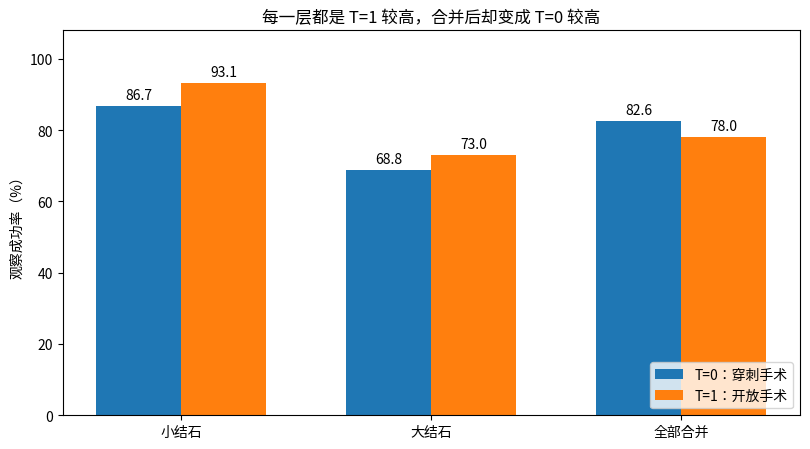

In [5]:
# 把分层结果和整体结果放在同一张图上。
positions = np.arange(len(rate_comparison))
width = 0.34
fig, ax = plt.subplots(figsize=(8.2, 4.6))
for offset, column, label in [
    (-width / 2, "T=0 成功率", "T=0：穿刺手术"),
    (width / 2, "T=1 成功率", "T=1：开放手术"),
]:
    bars = ax.bar(positions + offset, 100 * rate_comparison[column], width, label=label)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10)
ax.set_xticks(positions, rate_comparison.index)
ax.set_ylim(0, 108)
ax.set_ylabel("观察成功率（%）")
ax.set_title("每一层都是 T=1 较高，合并后却变成 T=0 较高")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

小结石这一层，$T=1$ 的成功率高约 6.44 个百分点；大结石这一层，高约 4.25 个百分点。但是合在一起，方向反过来了。这就是辛普森悖论：所有层内的关联方向一致，却与合并后的方向相反。

### 4. 问题出在两组人的构成

先检查两组中小结石、大结石各占多少。

两种处理各自的病例数：


结石大小,小结石,大结石
T,,
0,270,80
1,87,263


两种处理各自的病例构成（%）：


结石大小,小结石,大结石
T,,
0,77.14,22.86
1,24.86,75.14


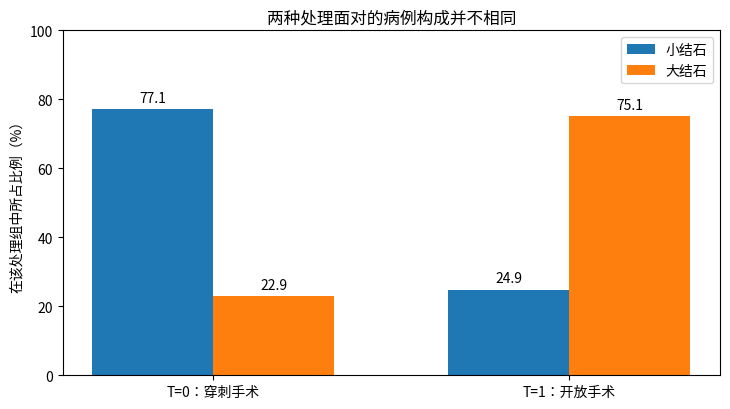

In [6]:
composition = (
    stone.pivot(index="T", columns="结石大小", values="总人数")
    .reindex(columns=["小结石", "大结石"])
)
weights_by_t = composition.div(composition.sum(axis=1), axis=0)

print("两种处理各自的病例数：")
display(composition)
print("两种处理各自的病例构成（%）：")
display((100 * weights_by_t).round(2))

fig, ax = plt.subplots(figsize=(7.4, 4.2))
x = np.arange(2)
for offset, group in [(-0.17, "小结石"), (0.17, "大结石")]:
    bars = ax.bar(x + offset, 100 * weights_by_t[group], 0.34, label=group)
    ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_xticks(x, ["T=0：穿刺手术", "T=1：开放手术"])
ax.set_ylim(0, 100)
ax.set_ylabel("在该处理组中所占比例（%）")
ax.set_title("两种处理面对的病例构成并不相同")
ax.legend()
fig.tight_layout()
plt.show()

$T=1$ 组中，大结石患者占多数；$T=0$ 组中，小结石患者占多数。而两种处理下，小结石患者的观察成功率都更高。

所以，整体成功率不是单纯在比较处理方式，还混合了病例构成的差异。把这个加权过程写出来：

$$
\widehat p_t
=\sum_x \widehat P(Y=1\mid T=t,X=x)\,\widehat P(X=x\mid T=t).
$$

第一项是各层的成功率，第二项是各层在该处理组中所占的比例。两个处理组使用的权重并不相同。[1，第 1.3.2 节]

下面按这个公式，把两组整体成功率重新算一遍。

In [7]:
# 先对齐层次顺序，再进行“每层成功率 × 该层权重”的求和。
weighted_rates = {}
for t in [0, 1]:
    w = weights_by_t.loc[t].reindex(strata.index)
    weighted_rates[t] = float(np.dot(w, strata[t]))
    print(
        f"T={t}: {w.iloc[0]:.4f} × {strata.loc['小结石', t]:.4f}"
        f" + {w.iloc[1]:.4f} × {strata.loc['大结石', t]:.4f}"
        f" = {weighted_rates[t]:.4f}"
    )
    np.testing.assert_allclose(weighted_rates[t], overall.loc[t, "成功率"])

T=0: 0.7714 × 0.8667 + 0.2286 × 0.6875 = 0.8257
T=1: 0.2486 × 0.9310 + 0.7514 × 0.7300 = 0.7800


再加一个计算练习：如果两组都使用全部 700 人的小结石、大结石比例，结果会怎样？这里仅统一加权时的病例构成，暂不把这个数当作已经识别出的因果效应。

In [8]:
common_weights = composition.sum(axis=0).reindex(strata.index) / composition.to_numpy().sum()
common_rates = pd.Series(
    {t: float(np.dot(common_weights, strata[t])) for t in [0, 1]},
    name="统一权重后的成功率"
)
common_diff = common_rates.loc[1] - common_rates.loc[0]

print("共同权重：")
display(common_weights.rename("比例").round(4).to_frame())
display(common_rates.round(4).to_frame())
print(f"共同权重下的差值：{100 * common_diff:.2f} 个百分点")

# 共同权重下，总体差值就是层内差值的加权平均。
np.testing.assert_allclose(common_diff, np.dot(common_weights, strata[1] - strata[0]))
assert common_diff > 0

共同权重：


,比例
结石大小,
小结石,0.51
大结石,0.49


,统一权重后的成功率
0,0.7789
1,0.8325


共同权重下的差值：5.37 个百分点


权重相同后，差值变成约 5.37 个百分点，落在两个层内差值之间。这个结果不神秘：两个正数的非负加权平均，仍然是正数。

但分层结果也不能自动变成因果结论。原表只给了结石大小、处理和结局，是否还有其他混杂因素，单凭这四行数据无法判断。因果识别的条件会在后面的笔记里展开。

这也说明一个区别：对固定目标人群，真正的平均处理效应是各子群效应按同一套人群比例加权的结果；在加性效应尺度上，不会出现“各子群真实平均效应都为正，整体真实平均效应却为负”的反转。[1，第 2.2.1 节]

## 完整案例二：生成潜在结局，再决定谁接受处理

现实表格没有给出反事实，下面改用模拟数据。沿用 Ding 第 2.3 节的设定：

$$
Y_i(0)\sim N(0,1),\qquad
\tau_i=-0.5+Y_i(0),\qquad
Y_i(1)=Y_i(0)+\tau_i.
$$

结局使用任意单位，并约定越大越好。这个模型不是对某项实际治疗的描述。

这里 $E[Y(0)]=0$，所以总体 ATE 是 $-0.5$。但每个人的效应不相同：当 $Y_i(0)>0.5$ 时，$\tau_i>0$，这个人会受益。

### 1. 生成完整表，先把真实答案留下来

先生成 500 个人的两个潜在结局。`truth` 存放模拟真值；后面另建 `observed` 存放观察数据，不把它们混为一张建模数据表。

In [9]:
n = 500
rng_data = np.random.default_rng(SEED_DATA)
y0 = rng_data.normal(loc=0, scale=1, size=n)
tau = -0.5 + y0
y1 = y0 + tau

truth = pd.DataFrame({
    "id": np.arange(1, n + 1),
    "Y0": y0,
    "Y1": y1,
    "tau": tau,
})
true_ate = float(truth["tau"].mean())
population_ate = -0.5

print("完整表的前 8 行（仅在模拟中能够完整看到）：")
display(truth.head(8).round(4))
print(f"这 {n} 个人的真实平均效应 ATE_n：{true_ate:.4f}")
print(f"数据生成总体的 ATE：{population_ate:.4f}")
print(f"真正受益的人所占比例：{(truth['tau'] > 0).mean():.2%}")

np.testing.assert_allclose(truth["Y1"] - truth["Y0"], truth["tau"])
np.testing.assert_allclose(true_ate, truth["Y1"].mean() - truth["Y0"].mean())

完整表的前 8 行（仅在模拟中能够完整看到）：


,id,Y0,Y1,tau
0,1,0.3047,0.1094,-0.1953
1,2,-1.0400,-2.5800,-1.5400
2,3,0.7505,1.0009,0.2505
3,4,0.9406,1.3811,0.4406
4,5,-1.9510,-4.4021,-2.4510
5,6,-1.3022,-3.1044,-1.8022
6,7,0.1278,-0.2443,-0.3722
7,8,-0.3162,-1.1325,-0.8162


这 500 个人的真实平均效应 ATE_n：-0.5131
数据生成总体的 ATE：-0.5000
真正受益的人所占比例：27.00%


样本的真实平均效应约为 -0.5131，不是恰好 -0.5。这不是估计出了偏差，而是生成出来的这 500 个人，其 $Y(0)$ 均值没有恰好等于总体均值 0。

后面在同一张完整表上比较处理分配方式时，用 `true_ate` 作为核对标准。不能一会儿拿样本真值比较，一会儿又换成总体的 -0.5。

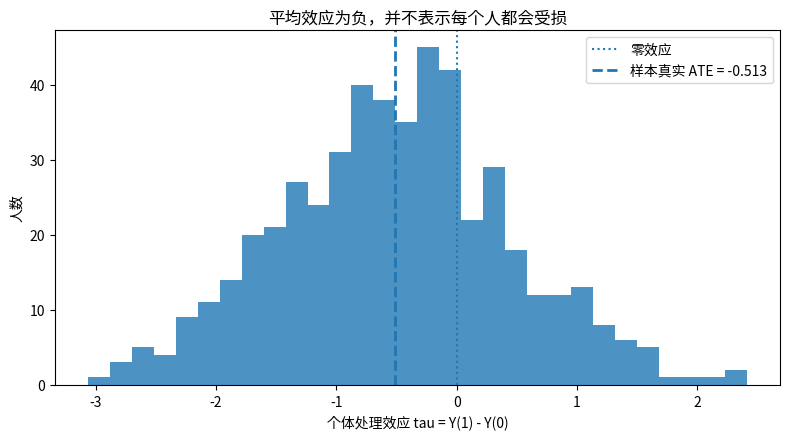

In [10]:
fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.hist(truth["tau"], bins=30, alpha=0.8)
ax.axvline(0, linestyle=":", linewidth=1.5, label="零效应")
ax.axvline(true_ate, linestyle="--", linewidth=2, label=f"样本真实 ATE = {true_ate:.3f}")
ax.set_xlabel("个体处理效应 tau = Y(1) - Y(0)")
ax.set_ylabel("人数")
ax.set_title("平均效应为负，并不表示每个人都会受损")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 随机分配处理，只保留能够观察到的结局

先给每个人独立地抛一枚公平硬币，决定他接受处理还是进入对照组。再根据处理状态，从 `Y1` 或 `Y0` 中取出实际结局。

`observed_random` 里只有编号、处理状态和观察结局。完整表保留在另一个对象中，只用于检验计算。

In [11]:
rng_assign = np.random.default_rng(SEED_ASSIGN)
t_random = rng_assign.binomial(n=1, p=0.5, size=n)
y_random = np.where(t_random == 1, truth["Y1"], truth["Y0"])
observed_random = pd.DataFrame({"id": truth["id"], "T": t_random, "Y": y_random})

display(observed_random.head(8).round(4))
print("两组人数：")
print(observed_random["T"].value_counts().sort_index().to_string())

# 把未被观察到的那一项遮住，看看现实数据缺了什么。
visible_table = pd.DataFrame({
    "id": truth["id"],
    "T": t_random,
    "Y0（可见部分）": np.where(t_random == 0, truth["Y0"], np.nan),
    "Y1（可见部分）": np.where(t_random == 1, truth["Y1"], np.nan),
    "观察结局 Y": y_random,
})
print("遮住反事实后的前 8 行：")
display(visible_table.head(8).round(4))
assert visible_table[["Y0（可见部分）", "Y1（可见部分）"]].isna().sum(axis=1).eq(1).all()

,id,T,Y
0,1,0,0.3047
1,2,1,-2.5800
2,3,0,0.7505
3,4,0,0.9406
4,5,0,-1.9510
5,6,1,-3.1044
6,7,1,-0.2443
7,8,0,-0.3162


两组人数：
T
0    252
1    248
遮住反事实后的前 8 行：


,id,T,Y0（可见部分）,Y1（可见部分）,观察结局 Y
0,1,0,0.3047,NaN,0.3047
1,2,1,NaN,-2.5800,-2.5800
2,3,0,0.7505,NaN,0.7505
3,4,0,0.9406,NaN,0.9406
4,5,0,-1.9510,NaN,-1.9510
5,6,1,NaN,-3.1044,-3.1044
6,7,1,NaN,-0.2443,-0.2443
7,8,0,-0.3162,NaN,-0.3162


表中的 `NaN` 表示这项潜在结局没有被观察到，不是录入错误，更不能当成 0。

两组的观察结局均值差，使用下面这个函数计算。函数只接收处理和观察结局，不接收 `tau` 或另一个潜在结局。

In [12]:
def difference_in_means(t: np.ndarray, y: np.ndarray) -> float:
    """计算观察结局的处理组均值减去对照组均值。"""
    t = np.asarray(t)
    y = np.asarray(y, dtype=float)
    if t.ndim != 1 or y.ndim != 1 or t.shape != y.shape:
        raise ValueError("t 和 y 必须是一维、等长数组。")
    if not np.isin(t, [0, 1]).all() or not np.isfinite(y).all():
        raise ValueError("t 只能取 0 或 1，y 必须为有限数值。")
    treated = t == 1
    if not treated.any() or treated.all():
        raise ValueError("必须同时存在处理组和对照组。")
    return float(y[treated].mean() - y[~treated].mean())

random_diff = difference_in_means(observed_random["T"], observed_random["Y"])
display(observed_random.groupby("T")["Y"].agg(["count", "mean", "std"]).round(4))
print(f"随机分配后的观察均值差：{random_diff:.4f}")
print(f"这 500 个人的真实平均效应：{true_ate:.4f}")
print(f"本次估计误差：{random_diff - true_ate:.4f}")

,count,mean,std
T,,,
0,252,-0.0124,0.9560
1,248,-0.5278,1.9316


随机分配后的观察均值差：-0.5154
这 500 个人的真实平均效应：-0.5131
本次估计误差：-0.0023


这次的均值差与样本真实效应很接近。但不能只靠这一次接近，就说方法总能得到准确答案。先保留这个结果，再换一种处理分配方式。

### 3. 只让能够受益的人接受处理

现在假设分配者事先知道每个人的真实效应：$\tau_i\geq 0$ 时才让他接受处理。这是原书中的假想例子，不是现实中能够直接执行的分配规则；我们只因为在做模拟，才知道每个人的 `tau`。[1，第 2.3 节]

两个潜在结局不变，只改变 $T$，再重新生成观察结局。

In [13]:
t_selected = (truth["tau"].to_numpy() >= 0).astype(int)
y_selected = np.where(t_selected == 1, truth["Y1"], truth["Y0"])
observed_selected = pd.DataFrame({"id": truth["id"], "T": t_selected, "Y": y_selected})
selected_diff = difference_in_means(observed_selected["T"], observed_selected["Y"])

print("按真实效应选择处理后的观察数据：")
display(observed_selected.head(8).round(4))
display(observed_selected.groupby("T")["Y"].agg(["count", "mean", "std"]).round(4))
print(f"观察均值差：{selected_diff:.4f}")
print(f"没有改变的样本真实 ATE：{true_ate:.4f}")

按真实效应选择处理后的观察数据：


,id,T,Y
0,1,0,0.3047
1,2,0,-1.0400
2,3,1,1.0009
3,4,1,1.3811
4,5,0,-1.9510
5,6,0,-1.3022
6,7,0,0.1278
7,8,0,-0.3162


,count,mean,std
T,,,
0,365,-0.4476,0.6798
1,135,1.8231,1.0424


观察均值差：2.2707
没有改变的样本真实 ATE：-0.5131


观察均值差变成了正数，而且远高于真实的样本 ATE。完整表没有变，改变的只是“哪些人进入了哪一组”。

### 4. 把 ATE、ATT 和观察均值差放在一起

ATE 对完整表中的全部人求平均。ATT 只对实际接受处理的人求平均，因此处理组成员变了，样本 ATT 也会跟着变。

下面借助模拟真值计算这两个量；在真实数据中，不能直接照着 `truth` 这一步计算。

In [14]:
assignments = {
    "随机分配": observed_random,
    "按真实效应选择": observed_selected,
}
rows = []
for name, observed in assignments.items():
    treated = observed["T"].to_numpy() == 1
    rows.append({
        "分配方式": name,
        "处理人数": int(treated.sum()),
        "观察均值差": difference_in_means(observed["T"], observed["Y"]),
        "真实 ATE_n": true_ate,
        "真实 ATT_n": float(truth.loc[treated, "tau"].mean()),
    })
comparison = pd.DataFrame(rows).set_index("分配方式")
display(comparison.round(4))

,处理人数,观察均值差,真实 ATE_n,真实 ATT_n
分配方式,,,,
随机分配,248,-0.5154,-0.5131,-0.5139
按真实效应选择,135,2.2707,-0.5131,0.6615


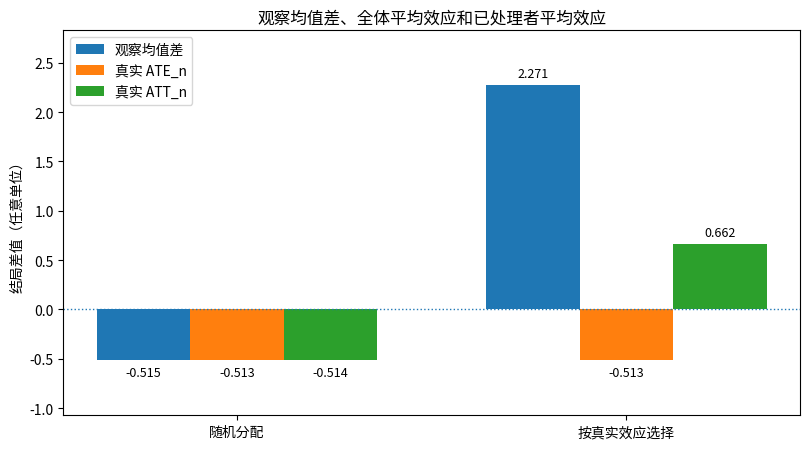

In [15]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
x = np.arange(len(comparison))
width = 0.24
for j, column in enumerate(["观察均值差", "真实 ATE_n", "真实 ATT_n"]):
    bars = ax.bar(x + (j - 1) * width, comparison[column], width, label=column)
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.axhline(0, linestyle=":", linewidth=1)
ax.set_xticks(x, comparison.index)
ax.set_ylabel("结局差值（任意单位）")
effect_values = comparison[["观察均值差", "真实 ATE_n", "真实 ATT_n"]].to_numpy()
lo, hi = min(0.0, effect_values.min()), max(0.0, effect_values.max())
padding = max(0.2, 0.2 * (hi - lo))
ax.set_ylim(lo - padding, hi + padding)
ax.set_title("观察均值差、全体平均效应和已处理者平均效应")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

按真实效应选择时，受处理者的真实 ATT 约为 0.6615，而全体的真实 ATE 约为 -0.5131。这两个数不矛盾：受处理者本来就是从全部人中挑出来的受益人群。

但观察均值差约为 2.2707，连 ATT 也没有准确反映。问题不只是选错了平均对象，还包括两组人在不处理状态下原本就不同。

### 5. 用完整表核对选择偏差

前面公式中的选择偏差，在这张固定模拟表里对应：

$$
B_n=\frac{1}{n_1}\sum_{T_i=1}Y_i(0)
-\frac{1}{n_0}\sum_{T_i=0}Y_i(0).
$$

其中 $n_1$、$n_0$ 分别是处理组和对照组人数。只要两组都非空，就有下面这个代数恒等式：

$$
\widehat\Delta=\operatorname{ATT}_n+B_n.
$$

对于随机分配的一次实现，$B_n$ 也可能不为零，那是偶然的组间不平衡；不应仅凭一次的非零值，就说随机化存在系统性选择偏差。

In [16]:
decomposition_rows = []
for name, observed in assignments.items():
    treated = observed["T"].to_numpy() == 1
    att_n = float(truth.loc[treated, "tau"].mean())
    baseline_gap = float(
        truth.loc[treated, "Y0"].mean() - truth.loc[~treated, "Y0"].mean()
    )
    observed_diff = difference_in_means(observed["T"], observed["Y"])
    decomposition_rows.append({
        "分配方式": name,
        "真实 ATT_n": att_n,
        "不处理潜在结局之差 B_n": baseline_gap,
        "ATT_n + B_n": att_n + baseline_gap,
        "观察均值差": observed_diff,
    })
    np.testing.assert_allclose(observed_diff, att_n + baseline_gap, atol=1e-12)

decomposition = pd.DataFrame(decomposition_rows).set_index("分配方式")
display(decomposition.round(4))

,真实 ATT_n,不处理潜在结局之差 B_n,ATT_n + B_n,观察均值差
分配方式,,,,
随机分配,-0.5139,-0.0015,-0.5154,-0.5154
按真实效应选择,0.6615,1.6091,2.2707,2.2707


在按效应选择的那一行，约 2.2707 的观察差异由两部分组成：0.6615 是这些受处理者的真实平均效应，另外约 1.6091 是两组在不处理状态下就存在的差异。

这几个数能被分开，是因为模拟完整表里保存了两个潜在结局。实际数据只告诉我们它们的合计，不能凭观察均值差单独拆出 ATT。

## 进一步分析

### 1. 随机分配一次不够，就重复分配看看

保持 `truth` 不变，重新随机分配处理 2,000 次。这次固定每组 250 人，再打乱组别；这是完全随机分配，与前面逐人抛硬币、人数不固定的做法稍有不同。[1，第 3.1 节]

每次都根据新的 $T$，重新从完整表中取出对应的观察结局。这里是在模拟反复开展试验，不是在对一份固定的观察结局做置换检验。

In [17]:
n_repeats = 2000
rng_mc = np.random.default_rng(SEED_MC)
assignment_template = np.r_[np.ones(n // 2, dtype=int), np.zeros(n - n // 2, dtype=int)]
random_diffs = np.empty(n_repeats)
y0_fixed = truth["Y0"].to_numpy()
y1_fixed = truth["Y1"].to_numpy()

for r in range(n_repeats):
    t = rng_mc.permutation(assignment_template)
    y = np.where(t == 1, y1_fixed, y0_fixed)
    random_diffs[r] = difference_in_means(t, y)

mc_mean = float(random_diffs.mean())
mc_sd = float(random_diffs.std(ddof=1))
mc_se_of_mean = mc_sd / np.sqrt(n_repeats)
mc_summary = pd.Series({
    "固定完整表的真实 ATE_n": true_ate,
    "2000 次观察均值差的平均值": mc_mean,
    "平均估计误差": mc_mean - true_ate,
    "单次估计在重复试验中的标准差": mc_sd,
    "2000 次平均值的 Monte Carlo 标准误": mc_se_of_mean,
})
display(mc_summary.round(5).to_frame("结果"))

,结果
固定完整表的真实 ATE_n,-0.51313
2000 次观察均值差的平均值,-0.51341
平均估计误差,-0.00028
单次估计在重复试验中的标准差,0.12953
2000 次平均值的 Monte Carlo 标准误,0.00290


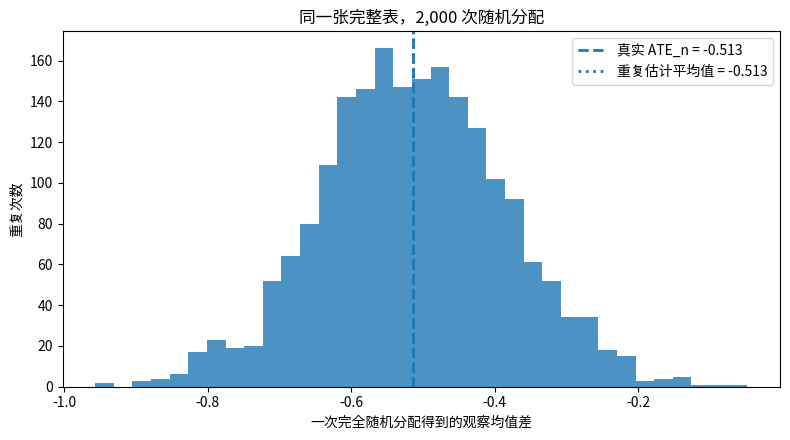

In [18]:
fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.hist(random_diffs, bins=35, alpha=0.8)
ax.axvline(true_ate, linestyle="--", linewidth=2, label=f"真实 ATE_n = {true_ate:.3f}")
ax.axvline(mc_mean, linestyle=":", linewidth=2, label=f"重复估计平均值 = {mc_mean:.3f}")
ax.set_xlabel("一次完全随机分配得到的观察均值差")
ax.set_ylabel("重复次数")
ax.set_title("同一张完整表，2,000 次随机分配")
ax.legend()
fig.tight_layout()
plt.show()

图里的每一次估计都有上下波动，但它们围绕同一个样本真实效应分布。随机化带来的好处，不是让两组在每次分配中都完全一样，而是避免总把某一类人分进同一组。

表中最后两行也要区分：单次估计的标准差描述重复试验中估计值的波动；Monte Carlo 标准误描述“把这 2,000 个估计取平均”以后，这个模拟平均值还剩多少数值不确定性。增加重复次数会让后者变小，不会让单次试验的数据变多。

### 2. 只增加样本量，能消除错误分组带来的问题吗？

再做一个扩展实验。仍使用原书的潜在结局模型，分别生成 100、500、2,000、10,000 人的数据，每种样本量重复 200 次。每次对同一张完整表分别采用随机分配和按真实效应选择，再与那张表的真实平均效应比较。

用均方根误差汇总：

$$
\operatorname{RMSE}
=\sqrt{\frac{1}{R}\sum_{r=1}^{R}
\bigl(\widehat\Delta_r-\operatorname{ATE}_{n,r}\bigr)^2}.
$$

这里每次都重新生成完整表，所以核对的样本真值 $\operatorname{ATE}_{n,r}$ 也随之改变。这个重复实验是对原书例子的扩展，不是原书的数值结果。

In [19]:
sample_sizes = [100, 500, 2000, 10000]
size_repeats = 200
rng_size = np.random.default_rng(SEED_SIZE)
error_records = []

for sample_n in sample_sizes:
    template = np.r_[np.ones(sample_n // 2, dtype=int),
                     np.zeros(sample_n - sample_n // 2, dtype=int)]
    for r in range(size_repeats):
        sample_y0 = rng_size.normal(size=sample_n)
        sample_tau = -0.5 + sample_y0
        sample_y1 = sample_y0 + sample_tau
        sample_ate = sample_tau.mean()
        treatment_rules = {
            "随机分配": rng_size.permutation(template),
            "按真实效应选择": (sample_tau >= 0).astype(int),
        }
        for name, t in treatment_rules.items():
            # 极小样本修改若造成某组为空，由均值差函数明确报错，而不是默默忽略。
            observed_y = np.where(t == 1, sample_y1, sample_y0)
            error = difference_in_means(t, observed_y) - sample_ate
            error_records.append({"样本量": sample_n, "分配方式": name, "误差": error})

errors = pd.DataFrame(error_records)
errors["平方误差"] = errors["误差"] ** 2
size_summary = errors.groupby(["样本量", "分配方式"]).agg(
    平均估计误差=("误差", "mean"),
    均方误差=("平方误差", "mean"),
    重复次数=("误差", "size"),
)
size_summary["RMSE"] = np.sqrt(size_summary["均方误差"])
display(size_summary[["平均估计误差", "RMSE", "重复次数"]].round(4))

平均估计误差    RMSE  重复次数
样本量   分配方式                         
100   按真实效应选择  2.7905  2.8001   200
      随机分配     0.0288  0.2965   200
500   按真实效应选择  2.7928  2.7943   200
      随机分配     0.0060  0.1305   200
2000  按真实效应选择  2.7934  2.7938   200
      随机分配    -0.0032  0.0713   200
10000 按真实效应选择  2.7894  2.7895   200
      随机分配     0.0012  0.0302   200

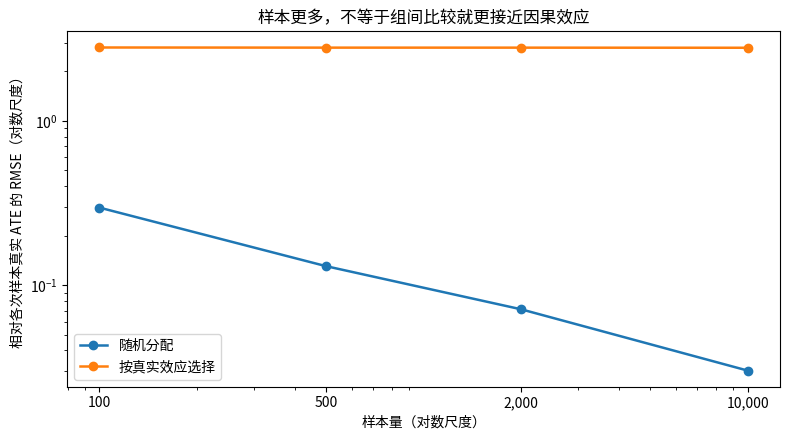

In [20]:
rmse_by_n = size_summary["RMSE"].unstack("分配方式")
fig, ax = plt.subplots(figsize=(8.0, 4.5))
for name in ["随机分配", "按真实效应选择"]:
    ax.plot(rmse_by_n.index, rmse_by_n[name], marker="o", linewidth=1.8, label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(sample_sizes, [f"{value:,}" for value in sample_sizes])
ax.set_xlabel("样本量（对数尺度）")
ax.set_ylabel("相对各次样本真实 ATE 的 RMSE（对数尺度）")
ax.set_title("样本更多，不等于组间比较就更接近因果效应")
ax.legend()
fig.tight_layout()
plt.show()

随机分配的误差随着样本量增加而下降，按效应选择的误差却没有一起趋近于零。后者的问题不是数据太少，而是观察均值差与想估计的 ATE 不是同一个量。

这不表示“让受益的人接受处理”是错误决策。错误的是：采用这种分配以后，还把两组的观察均值差直接解释为全体平均处理效应。决策是否合理，与这个估计方法是否回答了目标问题，需要分开讨论。

## 结果分析

回头看两个案例，计算方法都不复杂，问题出在比较对象。

肾结石数据中，两种处理的病例构成不同，整体成功率与分层成功率就可能给出相反方向。单靠“分层后变正了”，还不足以确认因果关系。

模拟数据中，两个潜在结局保持不变，仅仅改变谁接受处理，观察均值差就从负数变成了正数。ATE 没变，受处理者构成及其 ATT 变了，选择偏差项也变了。

随机化能够让平均效应的估计有依据，但它不会补出每个人缺失的反事实，也不会消除一次实验里的所有随机误差。下一篇再讨论随机试验中的检验和置信区间。

## 练习

### 1. 平均效应为正，是否意味着大多数人受益？

参考 Ding 第 2.4 节的习题 2.3，自己构造一组个体效应：平均值为正，但真正受益的人不到一半。下面给出一个可运行的例子，先想一想再运行。

In [21]:
# 一个自行构造的反例，不是实际观测数据。
exercise_tau = np.array([10, -1, -1, -1, -1, -1], dtype=float)
exercise_table = pd.DataFrame({
    "个体": np.arange(1, len(exercise_tau) + 1),
    "Y0": np.full(len(exercise_tau), 50.0),
    "Y1": 50.0 + exercise_tau,
    "tau": exercise_tau,
})
display(exercise_table)
print(f"平均处理效应：{exercise_tau.mean():.3f}")
print(f"受益者比例：{(exercise_tau > 0).mean():.2%}")
assert exercise_tau.mean() > 0
assert (exercise_tau > 0).mean() < 0.5

,个体,Y0,Y1,tau
0,1,50.0,60.0,10.0
1,2,50.0,49.0,-1.0
2,3,50.0,49.0,-1.0
3,4,50.0,49.0,-1.0
4,5,50.0,49.0,-1.0
5,6,50.0,49.0,-1.0


平均处理效应：0.833
受益者比例：16.67%


少数人的较大收益，可以超过多数人的较小损失。因此，“平均提高多少”与“有多少人提高”是两个不同的问题。

### 2. 同一份观察数据，能否对应不同的真实 ATE？

根据“每个人只观察到一项潜在结局”的定义，再做一个练习。固定下面四个人的处理和观察结局，只改变未观察到的那一项，分别构造“处理无效”和“处理使每个人增加 5 个单位”两种完整表。

这不是用一个模型估计缺失值，而是在检查：观察数据本身排除了哪些可能性？这个构造只要求与已观察到的 $T,Y$ 相容，未另外要求某种随机化分配模型。[1，第 2.2–2.3 节]

In [22]:
exercise_observed = pd.DataFrame({"T": [1, 1, 0, 0], "Y": [68.0, 74.0, 60.0, 75.0]})
t_obs = exercise_observed["T"].to_numpy()
y_obs = exercise_observed["Y"].to_numpy()

possible_tables = {}
for name, effect in [("完整表 A：每人效应为 0", 0.0), ("完整表 B：每人效应为 5", 5.0)]:
    # 由 Y = Y0 + T * effect 构造两项潜在结局。
    possible_y0 = y_obs - t_obs * effect
    possible_y1 = possible_y0 + effect
    table = pd.DataFrame({"T": t_obs, "观察 Y": y_obs, "Y0": possible_y0, "Y1": possible_y1})
    possible_tables[name] = table
    recovered_y = np.where(t_obs == 1, possible_y1, possible_y0)
    np.testing.assert_allclose(recovered_y, y_obs)
    print(name)
    display(table)
    print(f"这张完整表的真实 ATE：{(possible_y1 - possible_y0).mean():.1f}\n")

完整表 A：每人效应为 0


,T,观察 Y,Y0,Y1
0,1,68.0,68.0,68.0
1,1,74.0,74.0,74.0
2,0,60.0,60.0,60.0
3,0,75.0,75.0,75.0


这张完整表的真实 ATE：0.0

完整表 B：每人效应为 5


,T,观察 Y,Y0,Y1
0,1,68.0,63.0,68.0
1,1,74.0,69.0,74.0
2,0,60.0,60.0,65.0
3,0,75.0,75.0,80.0


这张完整表的真实 ATE：5.0



两张完整表给出的观察数据完全一样，真实 ATE 却不同。可见，给出了处理和观察结局，并不等于已经给出了反事实。还需要研究设计或额外假设，才能进一步约束可能的答案。

## 总结

因果效应比较的是同一个研究对象在不同处理状态下的潜在结局；观察均值差比较的是两组实际不同的人。只有说明两者为什么能够对应起来，组间差异才有因果解释。

ATE 和 ATT 的区别在于平均的目标人群。开始分析前，先明确要研究谁、比较哪两种处理、在什么时间测量什么结局，再考虑使用哪种估计方法。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. arXiv:2305.18793v2，2023-10-03。对应上传文件 `因果推断.pdf`。本篇主要使用第 1.3 节（正文第 7–9 页，肾结石与辛普森悖论）、第 2.2–2.3 节（第 16–20 页，潜在结局与分配机制）；另参考第 3.1 节（第 25–26 页，完全随机分配）、第 10.2 节（第 141–142 页，处理效应与选择偏差），以及习题 2.3（第 22 页）。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. Version 0.1.2，2026-05-03。对应上传文件 `CausalML_book_2022.pdf`，以扉页版本为准。参考第 2.1 节（正文第 44–48 页，潜在结局、ATE 与随机化）和第 5.5 节（第 145–146 页，分组效应与 ATET）。

本篇中的小型成绩表、补充练习、共同权重计算及重复模拟由上述概念展开；它们不是新增的真实研究数据。文中标为模拟的效应真值仅用于教学核对。